In [479]:
from itertools import count

import pandas as pd
import missingno as msno
import seaborn as sns
import numpy as np


In [480]:
dataset = pd.read_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_dataset_v0.csv')

# Detection de valeur manquante

In [481]:
dataset.isnull().mean()

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             0.027470
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 0.095639
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

<Axes: >

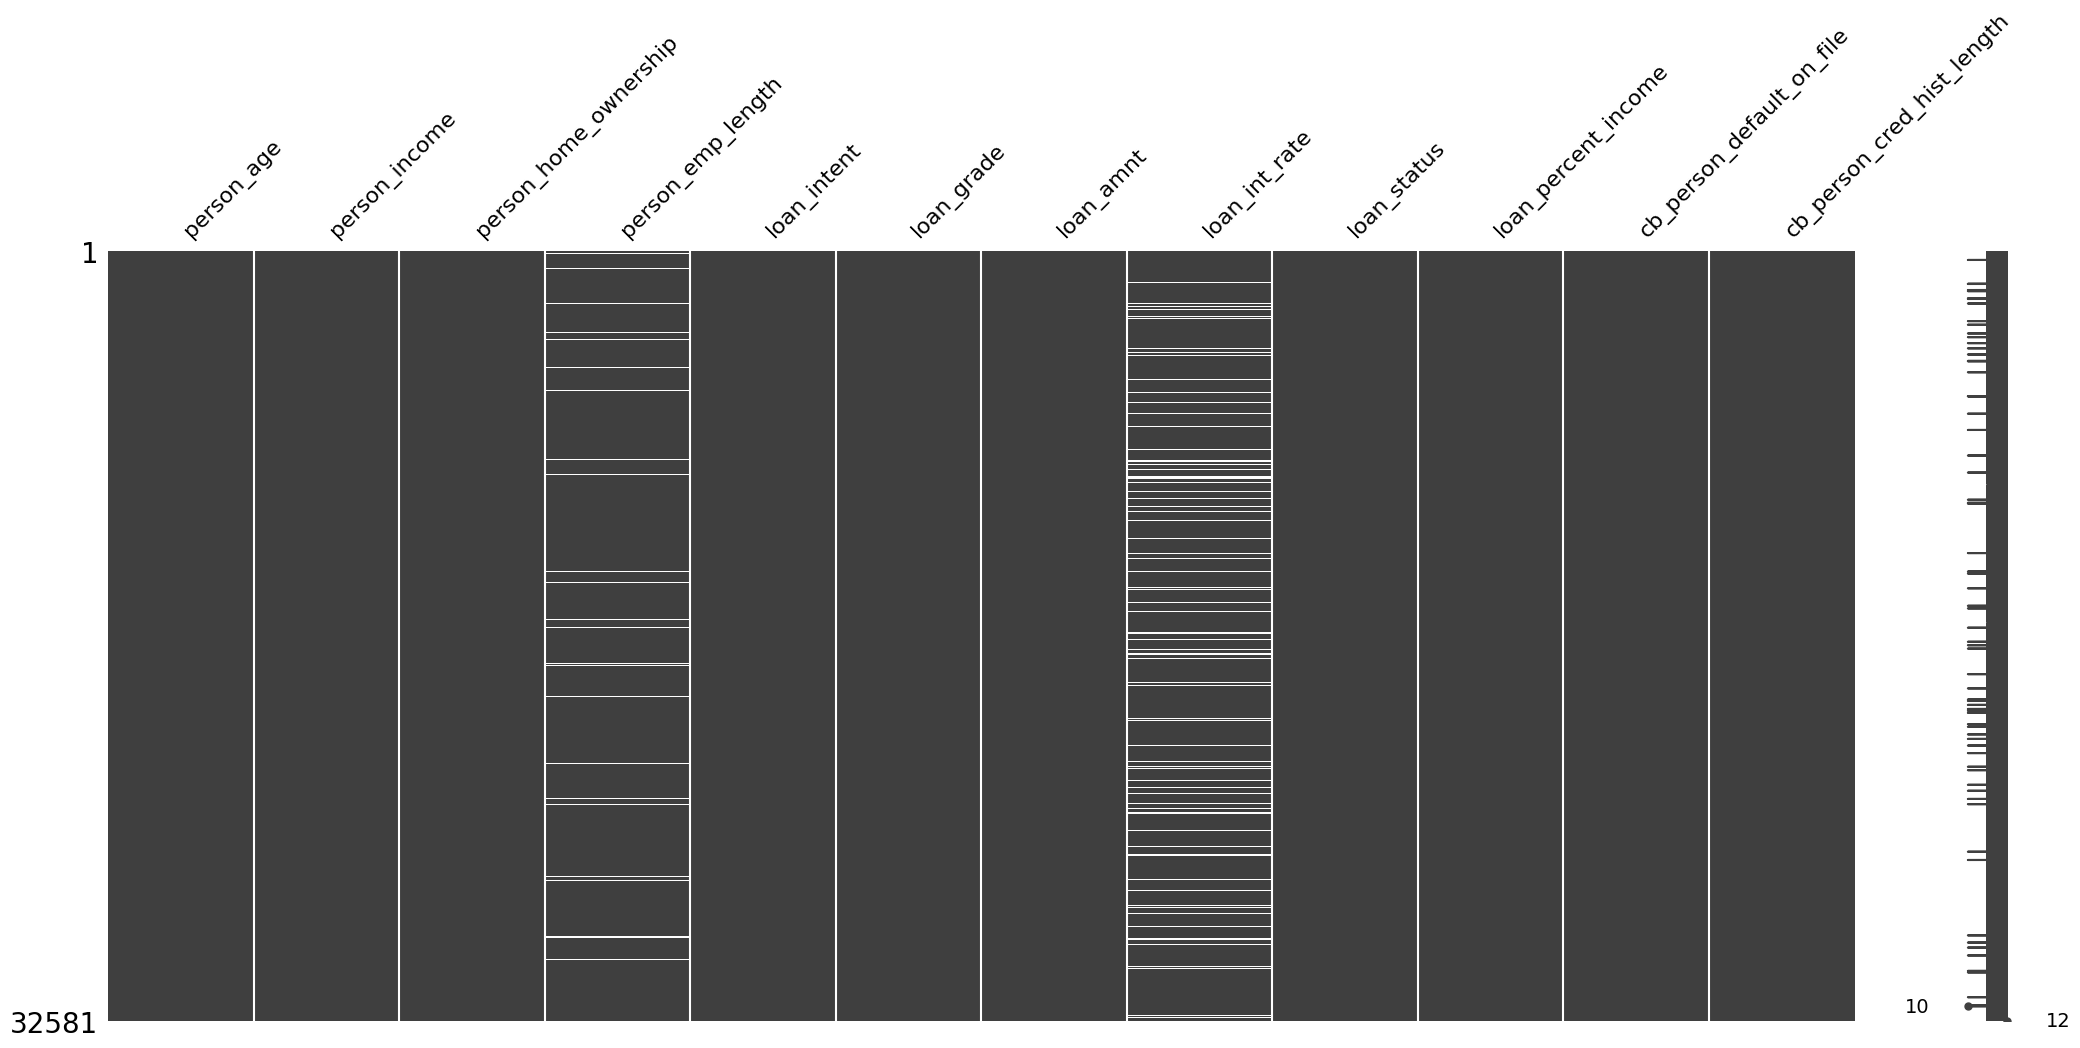

In [482]:
msno.matrix(dataset)

matrice de correlation des abscences. l'abscence est elle lie a une autre variable ?

<Axes: >

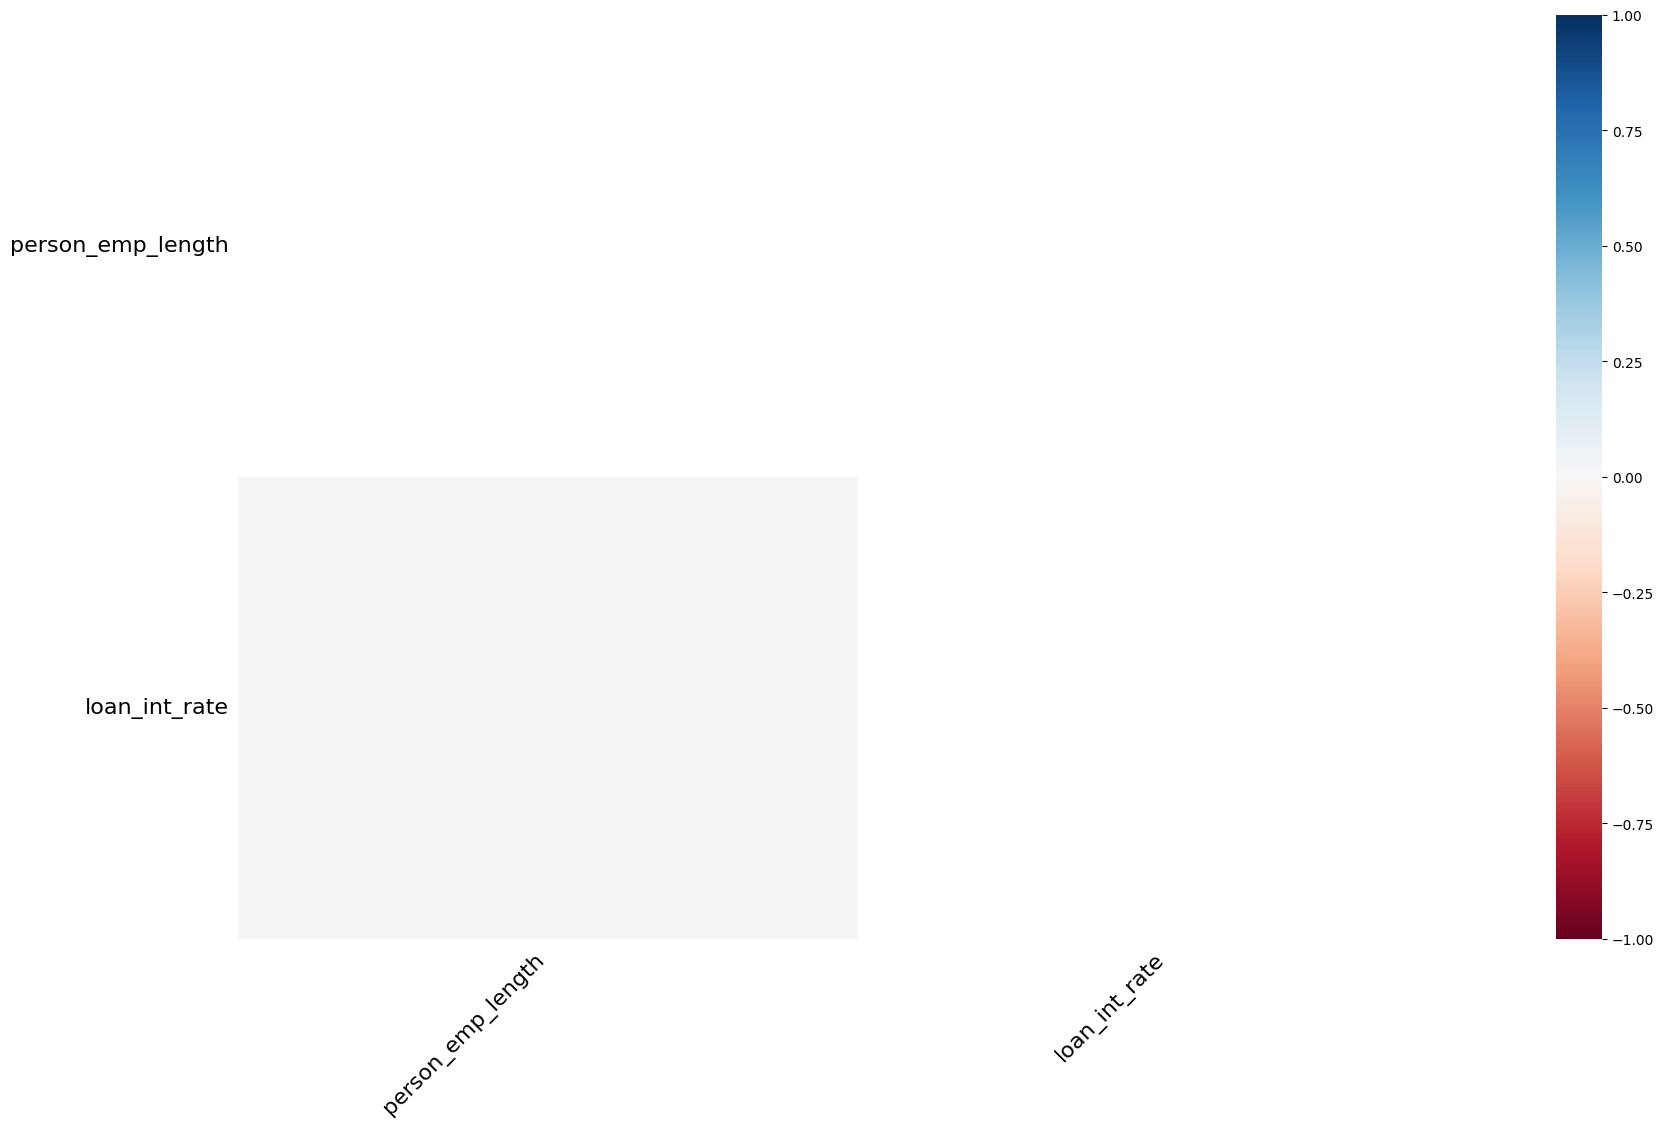

In [483]:
msno.heatmap(dataset)

- strat_01 Supprimer les colonne dont toute les valeur son null, seul condition  la nature du feature dependant

        Ici : aucun feature ayant les valeur null n'est dependant


In [484]:
dataset.dropna(axis='columns',how='any').shape[0]

32581

- strat_02 Si une ligne atteint une moyen 50% de valeur null alors suppresion de la ligne ( on definis un thresh )

In [485]:
dataset.dropna(axis='rows',thresh=0.50).shape[0]

32581

Postulat_1: les observation ayant experience nan, sont jeune et ne justifie pas d'experience en lesson vide la case

In [486]:
dataset[dataset['person_emp_length'].isna()]['person_age'].mean()

np.float64(27.28491620111732)

Postulat_2: les taux d'interet son omis pour des observation fragile, on verifie la note de credit

In [487]:
dataset[dataset['loan_int_rate'].isna()]['loan_grade'].mode()

0    B
Name: loan_grade, dtype: str

- Imputation loan_int_rate on a remarque que les taux interet nan avait des loan_grade B en majorite

In [488]:
data_imputed = dataset.copy()

In [489]:
#loan_int_rate par la median de ceux qui ont B
mean_B = data_imputed[data_imputed['loan_grade'] == 'B']['loan_int_rate'].mean()
data_imputed['loan_int_rate'] = data_imputed['loan_int_rate'].fillna(mean_B,axis=0)

-Imputation des person_emp_length

        creer une nouvelle dataset

In [490]:
# regrouper les observation en rang d'age
data_imputed['age_bin'] = pd.cut(
    data_imputed['person_age'],
    bins=[18, 25, 30, 40, 60],
    labels=['18-25', '25-30', '30-40', '40+']
)

In [491]:
# moyenne des experence par rang d'age
data_imputed.groupby('age_bin')['person_emp_length'].median()

age_bin
18-25    4.0
25-30    4.0
30-40    4.0
40+      4.0
Name: person_emp_length, dtype: float64

In [492]:
global_median = data_imputed['person_emp_length'].median()

# Calculer la médiane par groupe
group_median = data_imputed.groupby('age_bin')['person_emp_length']\
    .transform('median')

# Remplacer UNIQUEMENT les NaN
mask = data_imputed['person_emp_length'].isna()
data_imputed.loc[mask, 'person_emp_length'] = group_median[mask]

# Fallback global si des NaN persistent (groupe entièrement NaN)
data_imputed['person_emp_length'] = data_imputed['person_emp_length'].fillna(global_median)

In [493]:
data_imputed.isnull().mean()

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
age_bin                       0.002148
dtype: float64

In [494]:
data_imputed = data_imputed.drop('age_bin', axis=1)

In [495]:
dataset.shape

(32581, 12)

# Gestion des outlier

In [496]:
data_imputed.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

 person_age

<Axes: xlabel='person_age'>

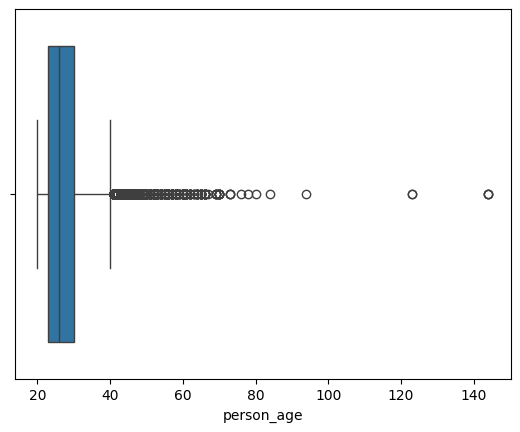

In [497]:
sns.boxplot(data_imputed, x ='person_age')

In [498]:
data_imputed.person_age.quantile([0.5,0.75,0.99,1])

0.50     26.0
0.75     30.0
0.99     50.0
1.00    144.0
Name: person_age, dtype: float64

In [499]:
data_imputed.person_age.describe()

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

- identify incoherence in data

                on fais une discretisation des age

In [500]:
data_imputed['age_groupe'] = pd.qcut(data_imputed['person_age'],q=4,labels=['20-26','26-30','30-50','50-144'] )
identify_incoherenc = data_imputed[data_imputed['age_groupe'] == '50-144']

identify_incoherenc.shape[0]



7757

            les  outlier acceptable  ont une limite d'age  de 80 ans , son electionne ceux qui sont vieux et incoherent

In [501]:
# recupere parmis les person en [50,144]
old_people =identify_incoherenc[identify_incoherenc.person_age > 80]
#on les regroupe par moyenne experience
old_people.groupby('person_age')['person_emp_length'].mean()

person_age
84     2.000000
94     1.000000
123    4.500000
144    6.666667
Name: person_emp_length, dtype: float64

In [502]:
old_people

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_groupe
81,144,250000,RENT,4.0,VENTURE,C,4800,13.570000,0,0.02,N,3,50-144
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.860000,0,0.03,N,2,50-144
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.250000,0,0.25,N,3,50-144
747,123,78000,RENT,7.0,VENTURE,B,20000,10.995555,0,0.26,N,4,50-144
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.730000,0,0.00,N,25,50-144
32416,94,24000,RENT,1.0,MEDICAL,C,6500,10.995555,0,0.27,N,27,50-144
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.510000,0,0.11,N,24,50-144


        effacer ceux qui sont incoherent en terme d'annees d'experience et d'age reel

In [503]:

mask = old_people[old_people['person_emp_length'] < 10]
data_imputed = data_imputed.drop(mask.index)

data_imputed = data_imputed[data_imputed['person_age'] <= 82]

        on peut aller plus loin,  observe les incoherence parmis les personne jeune avec des experience sureleve

In [504]:
young_people= data_imputed[data_imputed['age_groupe'] == '20-26']

young_people.groupby('person_age')['person_emp_length'].mean()

person_age
20    3.333333
21    3.328723
22    3.664740
23    3.936745
Name: person_emp_length, dtype: float64

        on cible ceux qui ont des experience irréaliste, exemple des jeune avec 23 ans ne peuvent pas avoir plus de 9 ans  d'experience

In [505]:


# Regle logique
data_imputed = data_imputed[ data_imputed['person_age'] - data_imputed['person_emp_length'] >= 16 ]

In [506]:
data_imputed.shape

(31834, 13)

person_emp_length

<Axes: xlabel='person_emp_length'>

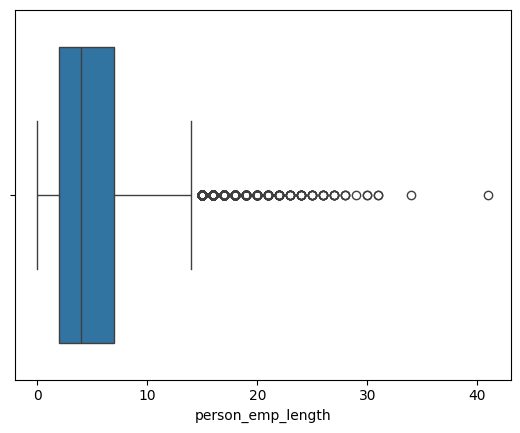

In [507]:
sns.boxplot(data_imputed, x ='person_emp_length')

    ON VEUT S'ASSURER QU'AUCUN JEUNE N'A ATTEINT UNE EXPERIENCE ABBERANTE

In [508]:
data_imputed[data_imputed['person_emp_length'] > 25]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_groupe
30171,42,48000,MORTGAGE,26.0,MEDICAL,A,6500,7.290000,0,0.14,N,11,50-144
30260,42,57996,RENT,26.0,VENTURE,A,6000,8.590000,0,0.10,N,12,50-144
30646,43,60000,MORTGAGE,27.0,HOMEIMPROVEMENT,B,10000,9.880000,0,0.17,N,16,50-144
30776,43,65000,MORTGAGE,27.0,VENTURE,A,6000,7.490000,0,0.09,N,17,50-144
30844,44,67000,MORTGAGE,28.0,HOMEIMPROVEMENT,B,3000,10.995555,0,0.04,N,14,50-144
30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,9000,14.540000,0,0.13,N,17,50-144
31042,42,62000,RENT,26.0,VENTURE,A,10000,8.490000,0,0.16,N,14,50-144
31171,42,62900,MORTGAGE,26.0,MEDICAL,C,3000,10.995555,1,0.04,N,14,50-144
31203,44,80000,MORTGAGE,28.0,VENTURE,D,25000,15.330000,0,0.31,Y,17,50-144
31646,43,47840,RENT,27.0,PERSONAL,B,15000,12.420000,1,0.31,N,12,50-144


In [509]:
data_imputed.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'age_groupe'],
      dtype='str')

PERSON_INCOME

<Axes: xlabel='person_income'>

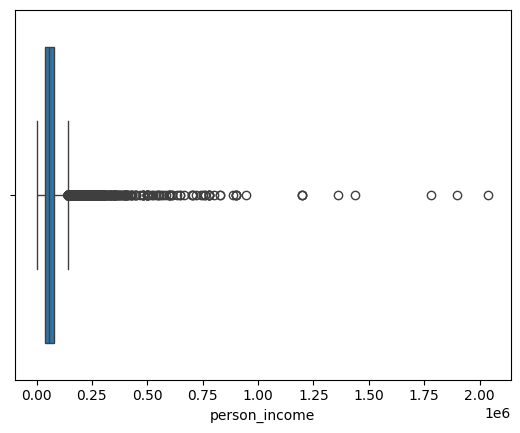

In [510]:
sns.boxplot(data_imputed, x ='person_income')

        PRESENCE DE GROS REVENU ON S'ASSURE QU'IL EST COHERENT EX : une person avec zero experience mais des revenu de 2 000 000

In [511]:
data_imputed[data_imputed['person_income'] > 700000]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_groupe
17833,32,1200000,MORTGAGE,1.0,VENTURE,A,12000,7.510000,0,0.01,N,8,50-144
17834,34,948000,MORTGAGE,18.0,PERSONAL,B,2000,9.990000,0,0.00,N,7,50-144
25714,32,703800,RENT,14.0,MEDICAL,D,12000,15.330000,1,0.01,Y,9,50-144
27882,31,741600,MORTGAGE,3.0,MEDICAL,B,12000,10.250000,0,0.02,N,6,50-144
27883,32,750000,MORTGAGE,2.0,DEBTCONSOLIDATION,B,30000,9.910000,0,0.04,N,8,50-144
27884,35,762000,OWN,8.0,MEDICAL,A,10000,8.940000,0,0.01,N,10,50-144
28253,35,762000,OWN,8.0,MEDICAL,A,10000,8.940000,0,0.01,N,8,50-144
29119,36,1200000,OWN,16.0,MEDICAL,A,10000,6.540000,0,0.01,N,11,50-144
29120,40,1200000,MORTGAGE,1.0,MEDICAL,A,10000,10.995555,0,0.01,N,16,50-144
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.690000,0,0.03,N,15,50-144


In [512]:
# toute personne avec plus d'un million de revenu sans experience est drop
mask = (data_imputed['person_income'] > 1000000) & (data_imputed['person_emp_length'] == 0.0)
data_imputed = data_imputed.drop(data_imputed[mask].index)
data_imputed.shape

(31833, 13)

LOAN_AMNT

<Axes: xlabel='loan_amnt'>

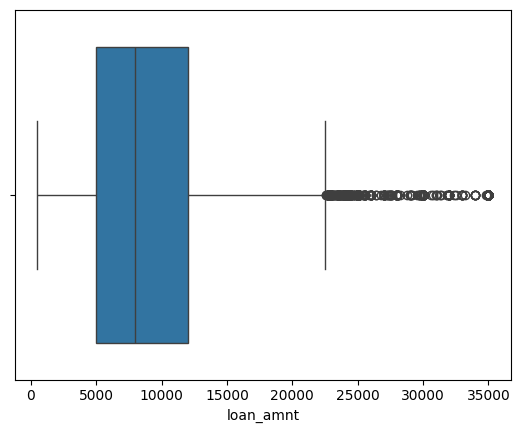

In [522]:
sns.boxplot(data_imputed, x ='loan_amnt')

        observation:
                Les montant de pret son acceptable

LOAN_INT_RATE

<Axes: xlabel='loan_int_rate'>

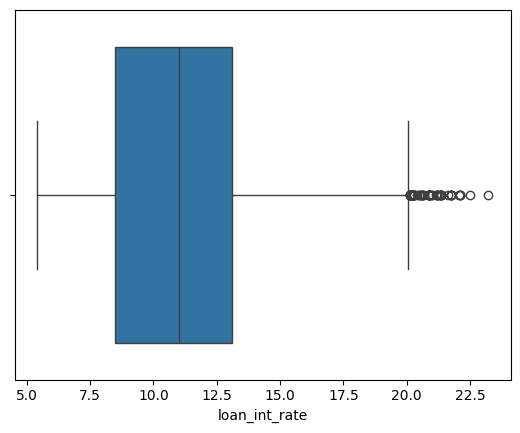

In [523]:
sns.boxplot(data_imputed, x ='loan_int_rate')

on cherche les taux d'intert qui depasse les 22%

In [528]:
data_imputed[data_imputed['loan_int_rate'] > 22]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_groupe
6449,23,34255,RENT,7.0,VENTURE,G,6000,22.11,1,0.18,Y,3,20-26
13499,26,44000,RENT,4.0,HOMEIMPROVEMENT,G,12500,22.11,1,0.28,Y,2,26-30
18829,31,22000,RENT,5.0,VENTURE,F,1400,22.06,0,0.06,Y,7,50-144
27425,28,128000,MORTGAGE,11.0,DEBTCONSOLIDATION,G,14400,22.11,1,0.11,Y,8,30-50
27851,28,288000,MORTGAGE,12.0,VENTURE,G,18000,22.48,1,0.06,Y,9,30-50
29277,38,83000,RENT,3.0,HOMEIMPROVEMENT,G,22250,23.22,1,0.27,Y,12,50-144


        Observation:
                On peut remarque des situation exceptionnel , ce serait des cas utile pour le model. en generale ces pret superieur sont dedier a des personne juger risqué

LOAN_PERCENT_INCOME

        la coherence des proucentage de pret dans les revenue depend  du ration loan_amt/person_income. on peut identifier l'incoherence pour imputer

<Axes: xlabel='loan_percent_income'>

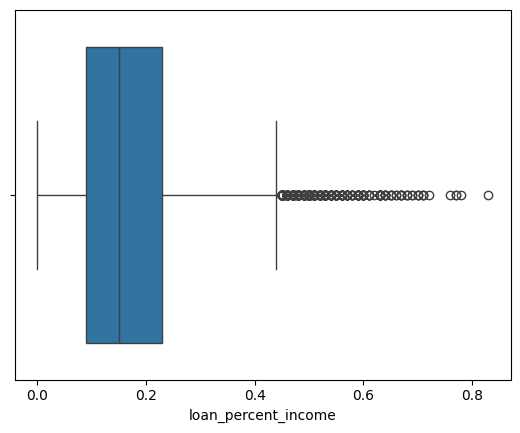

In [529]:
sns.boxplot(data_imputed, x ='loan_percent_income')

In [530]:
data_imputed.iloc[:,[1,6,9]]

,person_income,loan_amnt,loan_percent_income
1,9600,1000,0.10
2,9600,5500,0.57
3,65500,35000,0.53
4,54400,35000,0.55
5,9900,2500,0.25
...,...,...,...
32576,53000,5800,0.11
32577,120000,17625,0.15
32578,76000,35000,0.46
32579,150000,15000,0.10


        identifions ceux qui ne suivent pas la logique

In [541]:
#ceux dont les valeurs ne suive pas la logique
mask = data_imputed[
    (data_imputed['loan_amnt'] / data_imputed['person_income']).round(2) != data_imputed['loan_percent_income'].round(2)
].iloc[:, [1, 6, 9]]

mask



,person_income,loan_amnt,loan_percent_income
4,54400,35000,0.55
17,92111,35000,0.32
36,48000,30000,0.63
40,62050,30000,0.41
48,66300,30000,0.38
...,...,...,...
32480,62050,25000,0.34
32485,24000,3000,0.13
32542,200000,3000,0.01
32555,80000,18000,0.23


        on peut imputer suivant la logique

In [543]:
data_imputed.loc[mask.index,'loan_percent_income'] = (data_imputed.loc[mask.index,'loan_amnt'] / data_imputed.loc[mask.index , 'person_income'])
data_imputed.loc[mask.index,'loan_percent_income']

4        0.643382
17       0.379976
36       0.625000
40       0.483481
48       0.452489
           ...   
32480    0.402901
32485    0.125000
32542    0.015000
32555    0.225000
32569    0.125000
Name: loan_percent_income, Length: 986, dtype: float64

32581

        Observation :
                quelque incoherence on ete ajuste dans le ration loan_amnt/person_income

Verifions combien nous avons perdu en terme d'information

In [547]:
total_cleaned = dataset.shape[0] - data_imputed.shape[0]
total_cleaned

748

quel pourcentage pour les groupe defaut et non defaut du target ?

In [561]:
mask = dataset[~dataset.index.isin(data_imputed.index)]
value_count = mask['loan_status'].value_counts()

value_count = ( value_count/dataset.shape[0] )* 100
value_count



loan_status
0    1.835426
1    0.460391
Name: count, dtype: float64

Observation :

            la part des observation supprimer et qui sont  en defaut est faible , on a cleaning pas tres restrictive, ce qui nous laisse sufisament d'information pour le model

Ecrire le data set dans un csv

In [563]:
data_imputed.to_csv(
    '/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_cleansed_dataset_v0.csv',
    sep=',',  # virgule standard
    index=False
)